# EDA 01 — NSRDB Himawari Data Quality & Exploration

**Goals (per Phase 1 plan):**
1. Confirm 10-minute continuity across all 7 sites and 5 years (2016–2020)
2. Identify missing data periods and fill flags
3. Compute clear-sky index (CSI = GHI / Clearsky GHI)
4. Plot GHI distributions per site and per monsoon season
5. Visualise monsoon phase transitions vs GHI patterns

**Monsoon phases (Malaysia / SEA):**
- Northeast monsoon: Nov–Mar (months 11, 12, 1, 2, 3)
- Inter-monsoon I: Apr (month 4)
- Southwest monsoon: May–Sep (months 5, 6, 7, 8, 9)
- Inter-monsoon II: Oct (month 10)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join('..', 'data', 'nsrdb')
FIG_DIR  = os.path.join('..', 'data', 'processed', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

SITES = [
    'kuala_lumpur',
    'penang',
    'kota_kinabalu',
    'ho_chi_minh',
    'bangkok',
    'jakarta',
    'manila',
]

YEARS = [2016, 2017, 2018, 2019, 2020]

MONSOON_LABELS = {
    1:  'NE Monsoon',
    2:  'NE Monsoon',
    3:  'NE Monsoon',
    4:  'Inter-monsoon I',
    5:  'SW Monsoon',
    6:  'SW Monsoon',
    7:  'SW Monsoon',
    8:  'SW Monsoon',
    9:  'SW Monsoon',
    10: 'Inter-monsoon II',
    11: 'NE Monsoon',
    12: 'NE Monsoon',
}

MONSOON_ORDER = ['NE Monsoon', 'Inter-monsoon I', 'SW Monsoon', 'Inter-monsoon II']

print('Setup complete.')

Setup complete.


## 1. Load All NSRDB Data

In [2]:
def load_nsrdb(site, year):
    """Load a single NSRDB site-year CSV. Returns DataFrame with DatetimeIndex (UTC)."""
    path = os.path.join(DATA_DIR, f'{site}_{year}.csv')
    # Row 0: metadata, Row 1: units, Row 2: column headers, Row 3+: data
    df = pd.read_csv(path, skiprows=2, low_memory=False)
    df['timestamp'] = pd.to_datetime({
        'year':   df['Year'],
        'month':  df['Month'],
        'day':    df['Day'],
        'hour':   df['Hour'],
        'minute': df['Minute'],
    })
    df = df.set_index('timestamp')
    df = df.drop(columns=['Year', 'Month', 'Day', 'Hour', 'Minute'])
    df['site']  = site
    df['year']  = year
    df['month'] = df.index.month
    df['monsoon_phase'] = df['month'].map(MONSOON_LABELS)
    # Clear-sky index — clip to [0, 2] to remove sensor noise artefacts
    cs = df['Clearsky GHI'].replace(0, np.nan)
    df['CSI'] = (df['GHI'] / cs).clip(0, 2)
    return df

# Load all sites and years
all_dfs = {}
for site in SITES:
    frames = [load_nsrdb(site, y) for y in YEARS]
    all_dfs[site] = pd.concat(frames)
    print(f'{site}: {len(all_dfs[site]):,} rows')

print('\nAll sites loaded.')

kuala_lumpur: 263,088 rows


penang: 263,088 rows


kota_kinabalu: 263,088 rows


ho_chi_minh: 263,088 rows


bangkok: 263,088 rows


jakarta: 263,088 rows


manila: 263,088 rows

All sites loaded.


## 2. Continuity Check — 10-Minute Gaps

In [3]:
print(f"{'Site':<20} {'Expected rows':>15} {'Actual rows':>12} {'Missing':>10} {'Max gap (min)':>15}")
print('-' * 75)

for site, df in all_dfs.items():
    expected = int(365.25 * 24 * 6 * 5)
    actual   = len(df)
    missing  = expected - actual

    diffs   = df.index.to_series().diff().dt.total_seconds() / 60
    max_gap = diffs[diffs > 10].max() if (diffs > 10).any() else 0
    gap_str = f'{max_gap:.0f}' if max_gap > 0 else 'none'

    print(f"{site:<20} {expected:>15,} {actual:>12,} {missing:>10,} {gap_str:>15}")


Site                   Expected rows  Actual rows    Missing   Max gap (min)
---------------------------------------------------------------------------
kuala_lumpur                 262,980      263,088       -108            none
penang                       262,980      263,088       -108            none
kota_kinabalu                262,980      263,088       -108            none
ho_chi_minh                  262,980      263,088       -108            none
bangkok                      262,980      263,088       -108            none
jakarta                      262,980      263,088       -108            none
manila                       262,980      263,088       -108            none


## 3. Missing Data & Fill Flags

In [4]:
# Fill Flag meanings: 0=OK, 1=Missing image, 2=Low irradiance,
# 3=Exceeds clearsky, 4=Missing cloud properties, 5=Rayleigh violation

print(f"{'Site':<20} {'Flag=0 (OK)':>12} {'Flag=1':>8} {'Flag=2':>8} {'Flag=3':>8} {'Flag=4':>8} {'Flag=5':>8}")
print('-' * 80)

for site, df in all_dfs.items():
    counts = df['Fill Flag'].value_counts().sort_index()
    total  = len(df)
    row    = f'{site:<20}'
    for flag in range(6):
        n   = counts.get(flag, 0)
        pct = 100 * n / total
        row += f' {pct:>7.1f}%'
    print(row)


Site                  Flag=0 (OK)   Flag=1   Flag=2   Flag=3   Flag=4   Flag=5
--------------------------------------------------------------------------------
kuala_lumpur            89.1%     1.8%     0.0%     7.4%     0.0%     1.7%
penang                  87.8%     3.3%     0.0%     6.8%     0.0%     2.0%
kota_kinabalu           87.2%     3.6%     0.0%     7.7%     0.0%     1.5%
ho_chi_minh             88.9%     2.1%     0.0%     7.9%     0.0%     1.2%
bangkok                 90.0%     1.9%     0.0%     6.3%     0.0%     1.8%
jakarta                 89.7%     1.8%     0.0%     6.2%     0.0%     2.3%
manila                  85.6%     3.2%     0.0%     9.8%     0.0%     1.4%


## 4. GHI Distribution by Site

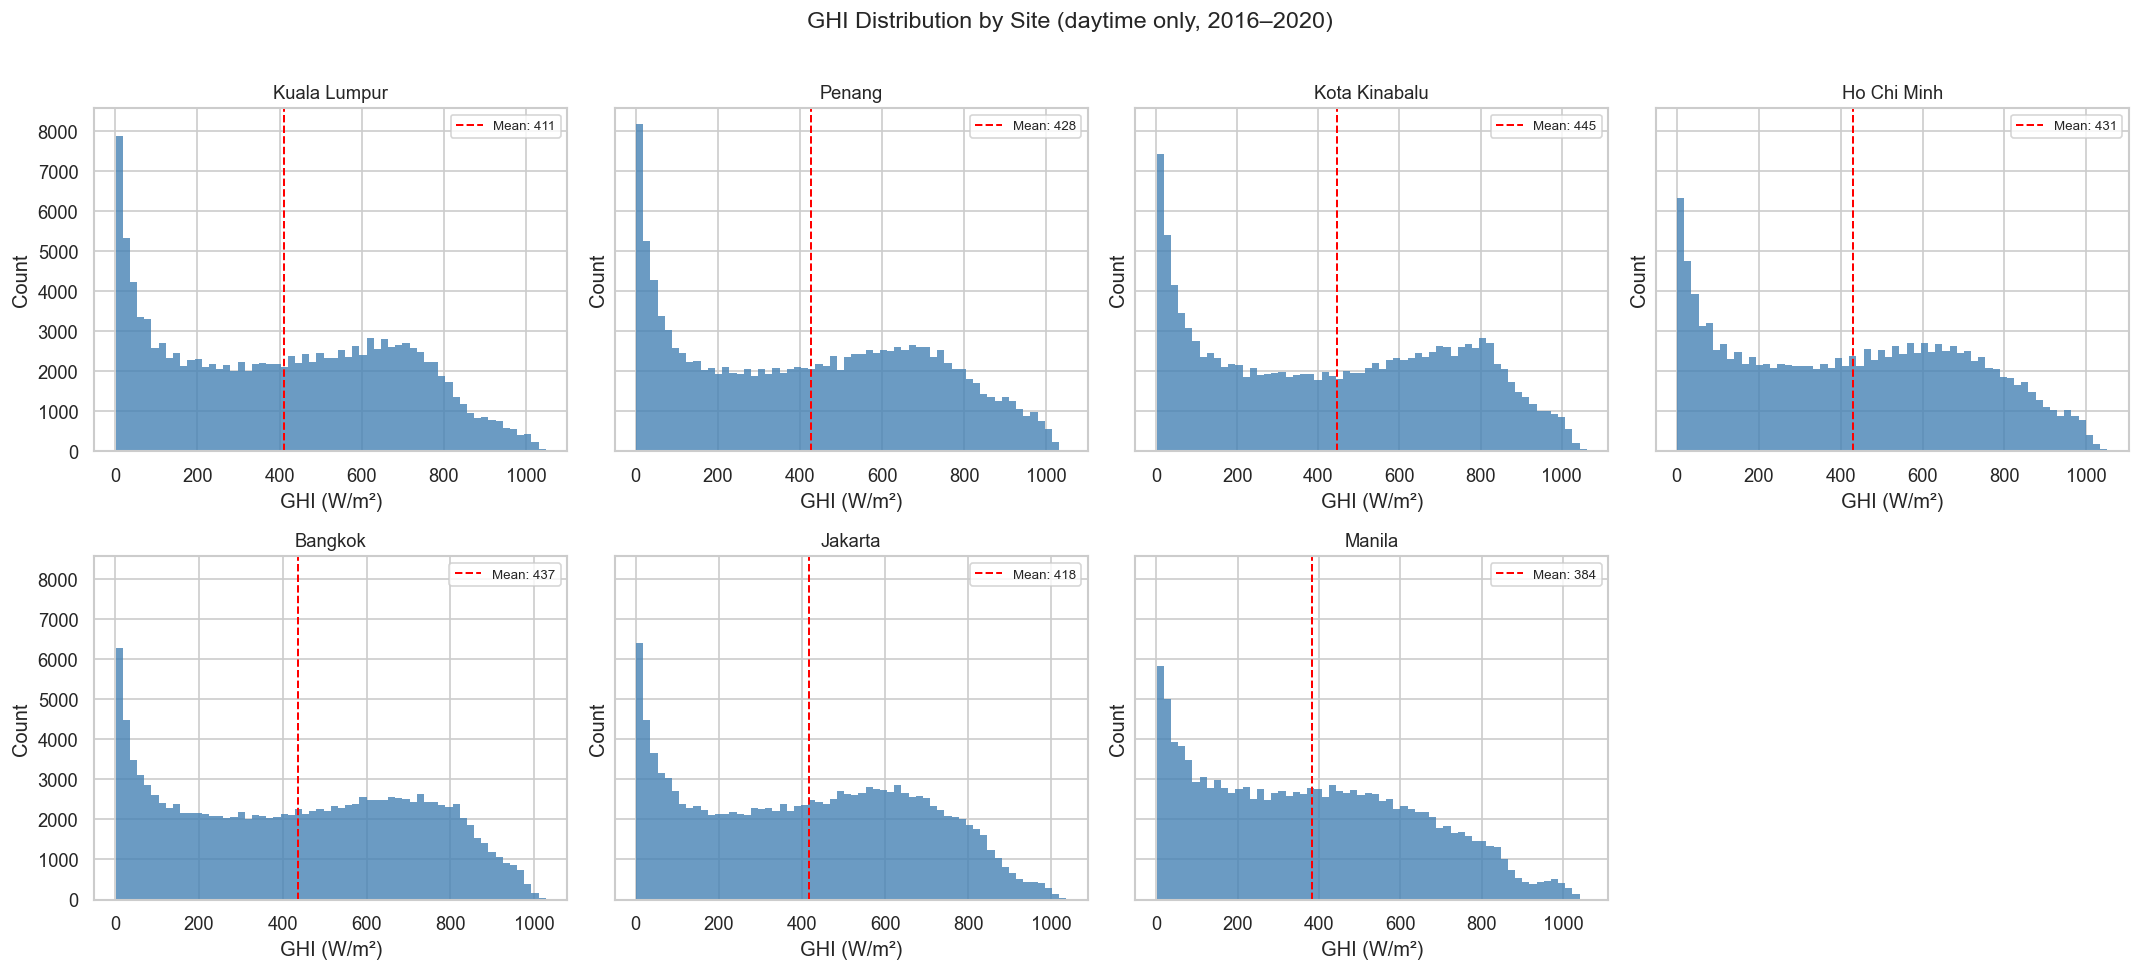

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, site in enumerate(SITES):
    ax = axes[i]
    # Daytime only (GHI > 0)
    daytime = all_dfs[site][all_dfs[site]['GHI'] > 0]['GHI']
    ax.hist(daytime, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(site.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('GHI (W/m²)')
    ax.set_ylabel('Count')
    mean_ghi = daytime.mean()
    ax.axvline(mean_ghi, color='red', linewidth=1.2, linestyle='--', label=f'Mean: {mean_ghi:.0f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('GHI Distribution by Site (daytime only, 2016–2020)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ghi_distribution_by_site.png'), bbox_inches='tight')
plt.show()

## 5. GHI Distribution by Monsoon Season (KL)

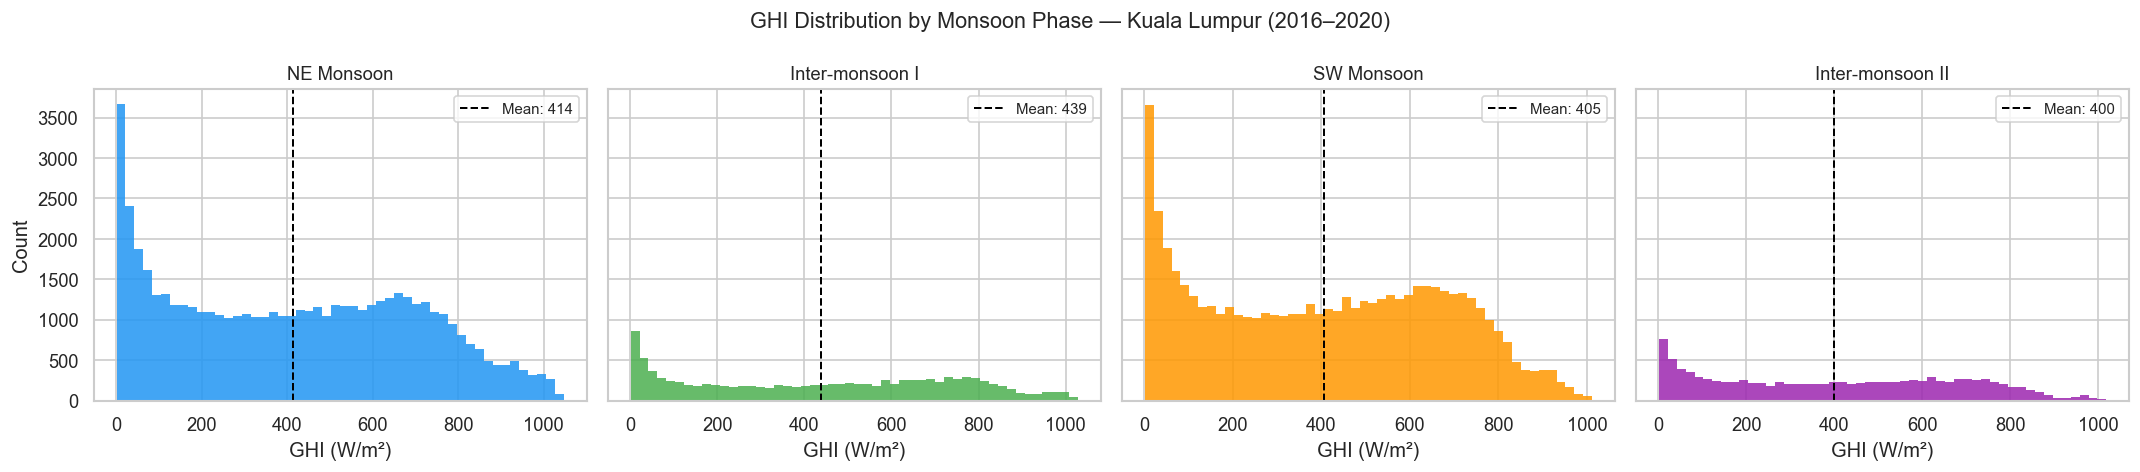

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

kl = all_dfs['kuala_lumpur']
kl_daytime = kl[kl['GHI'] > 0]

colors = {'NE Monsoon': '#2196F3', 'Inter-monsoon I': '#4CAF50',
          'SW Monsoon': '#FF9800', 'Inter-monsoon II': '#9C27B0'}

for ax, phase in zip(axes, MONSOON_ORDER):
    data = kl_daytime[kl_daytime['monsoon_phase'] == phase]['GHI']
    ax.hist(data, bins=50, color=colors[phase], edgecolor='none', alpha=0.85)
    ax.set_title(phase, fontsize=11)
    ax.set_xlabel('GHI (W/m²)')
    mean_val = data.mean()
    ax.axvline(mean_val, color='black', linewidth=1.2, linestyle='--', label=f'Mean: {mean_val:.0f}')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Count')
fig.suptitle('GHI Distribution by Monsoon Phase — Kuala Lumpur (2016–2020)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ghi_by_monsoon_kl.png'), bbox_inches='tight')
plt.show()

## 6. GHI Distribution by Monsoon Season — All Sites

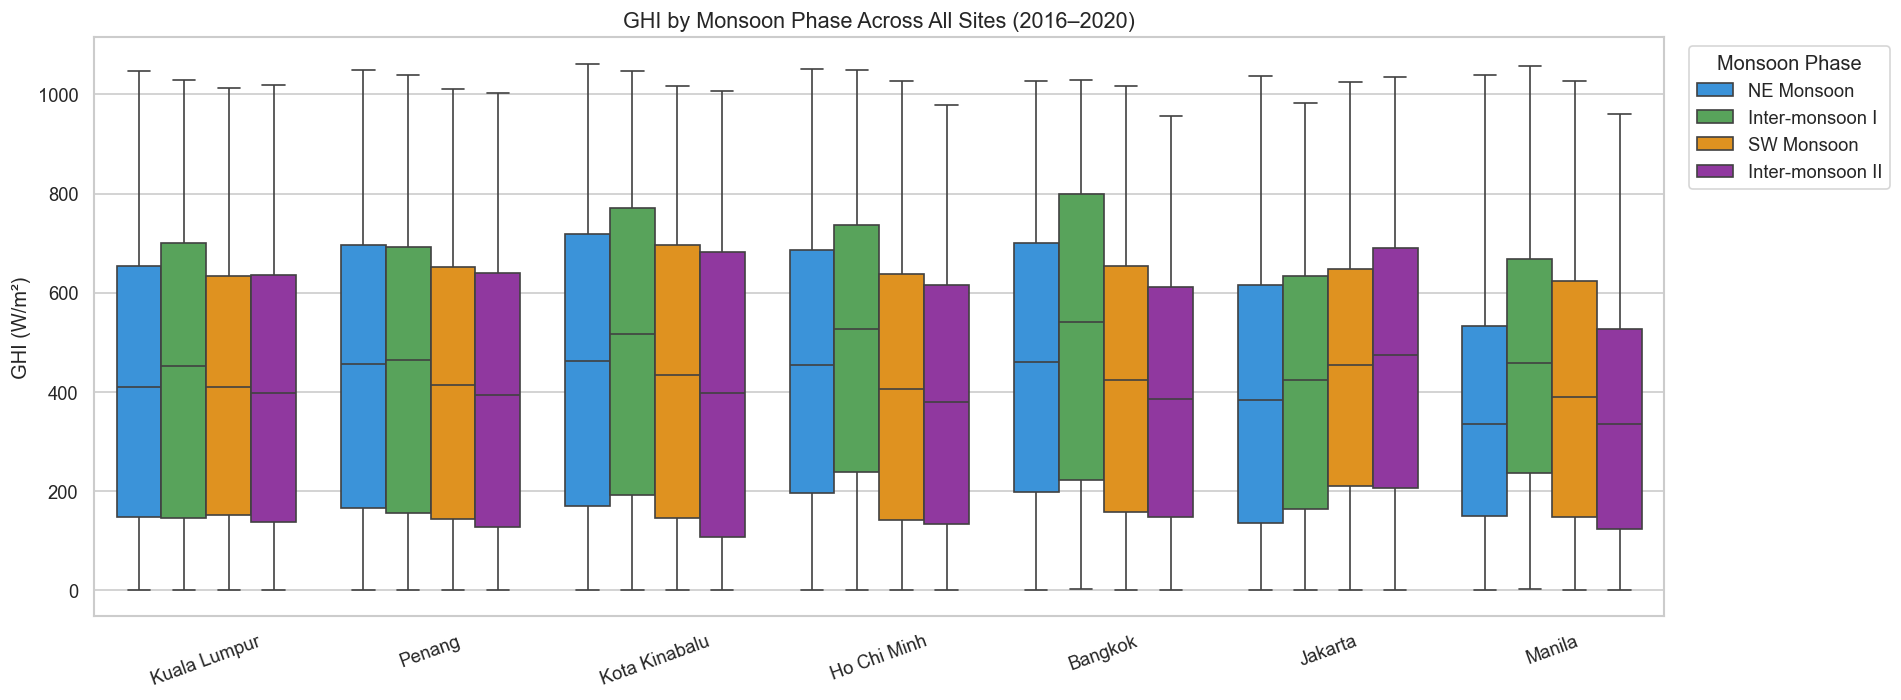

In [7]:
# Boxplot: monsoon phase vs GHI per site
records = []
for site, df in all_dfs.items():
    daytime = df[df['GHI'] > 0][['GHI', 'monsoon_phase']].copy()
    daytime['site'] = site.replace('_', ' ').title()
    records.append(daytime)

combined = pd.concat(records)
combined['monsoon_phase'] = pd.Categorical(combined['monsoon_phase'], categories=MONSOON_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(
    data=combined, x='site', y='GHI', hue='monsoon_phase',
    hue_order=MONSOON_ORDER, palette=colors, fliersize=1, ax=ax
)
ax.set_title('GHI by Monsoon Phase Across All Sites (2016–2020)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('GHI (W/m²)')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Monsoon Phase', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ghi_by_monsoon_all_sites.png'), bbox_inches='tight')
plt.show()

## 7. Monthly Mean GHI — Monsoon Transition Pattern

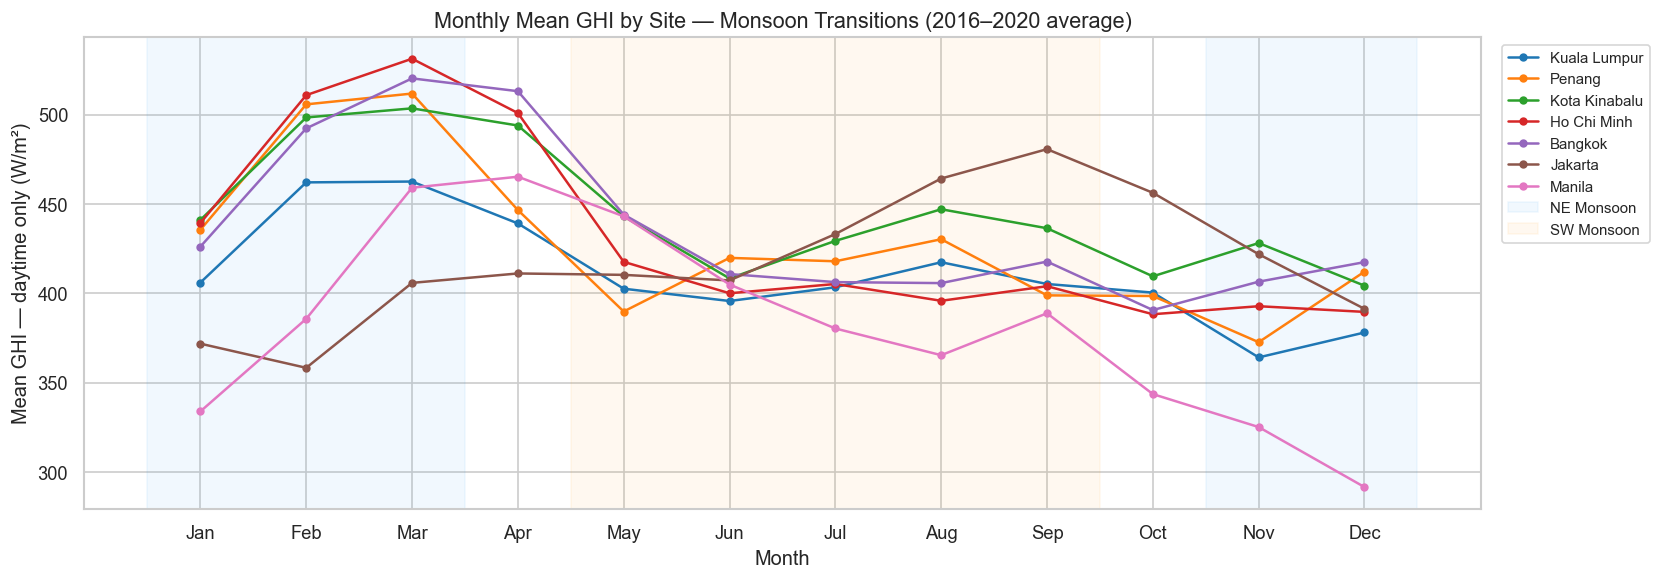

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for site, df in all_dfs.items():
    monthly = df[df['GHI'] > 0].groupby('month')['GHI'].mean()
    ax.plot(monthly.index, monthly.values, marker='o', linewidth=1.5,
            markersize=4, label=site.replace('_', ' ').title())

# Shade monsoon phases
ax.axvspan(0.5, 3.5,  alpha=0.06, color='#2196F3', label='NE Monsoon')
ax.axvspan(4.5, 9.5,  alpha=0.06, color='#FF9800', label='SW Monsoon')
ax.axvspan(10.5, 12.5, alpha=0.06, color='#2196F3')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Mean GHI — daytime only (W/m²)')
ax.set_title('Monthly Mean GHI by Site — Monsoon Transitions (2016–2020 average)', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'monthly_mean_ghi_monsoon.png'), bbox_inches='tight')
plt.show()

## 8. Clear-Sky Index (CSI) Distribution

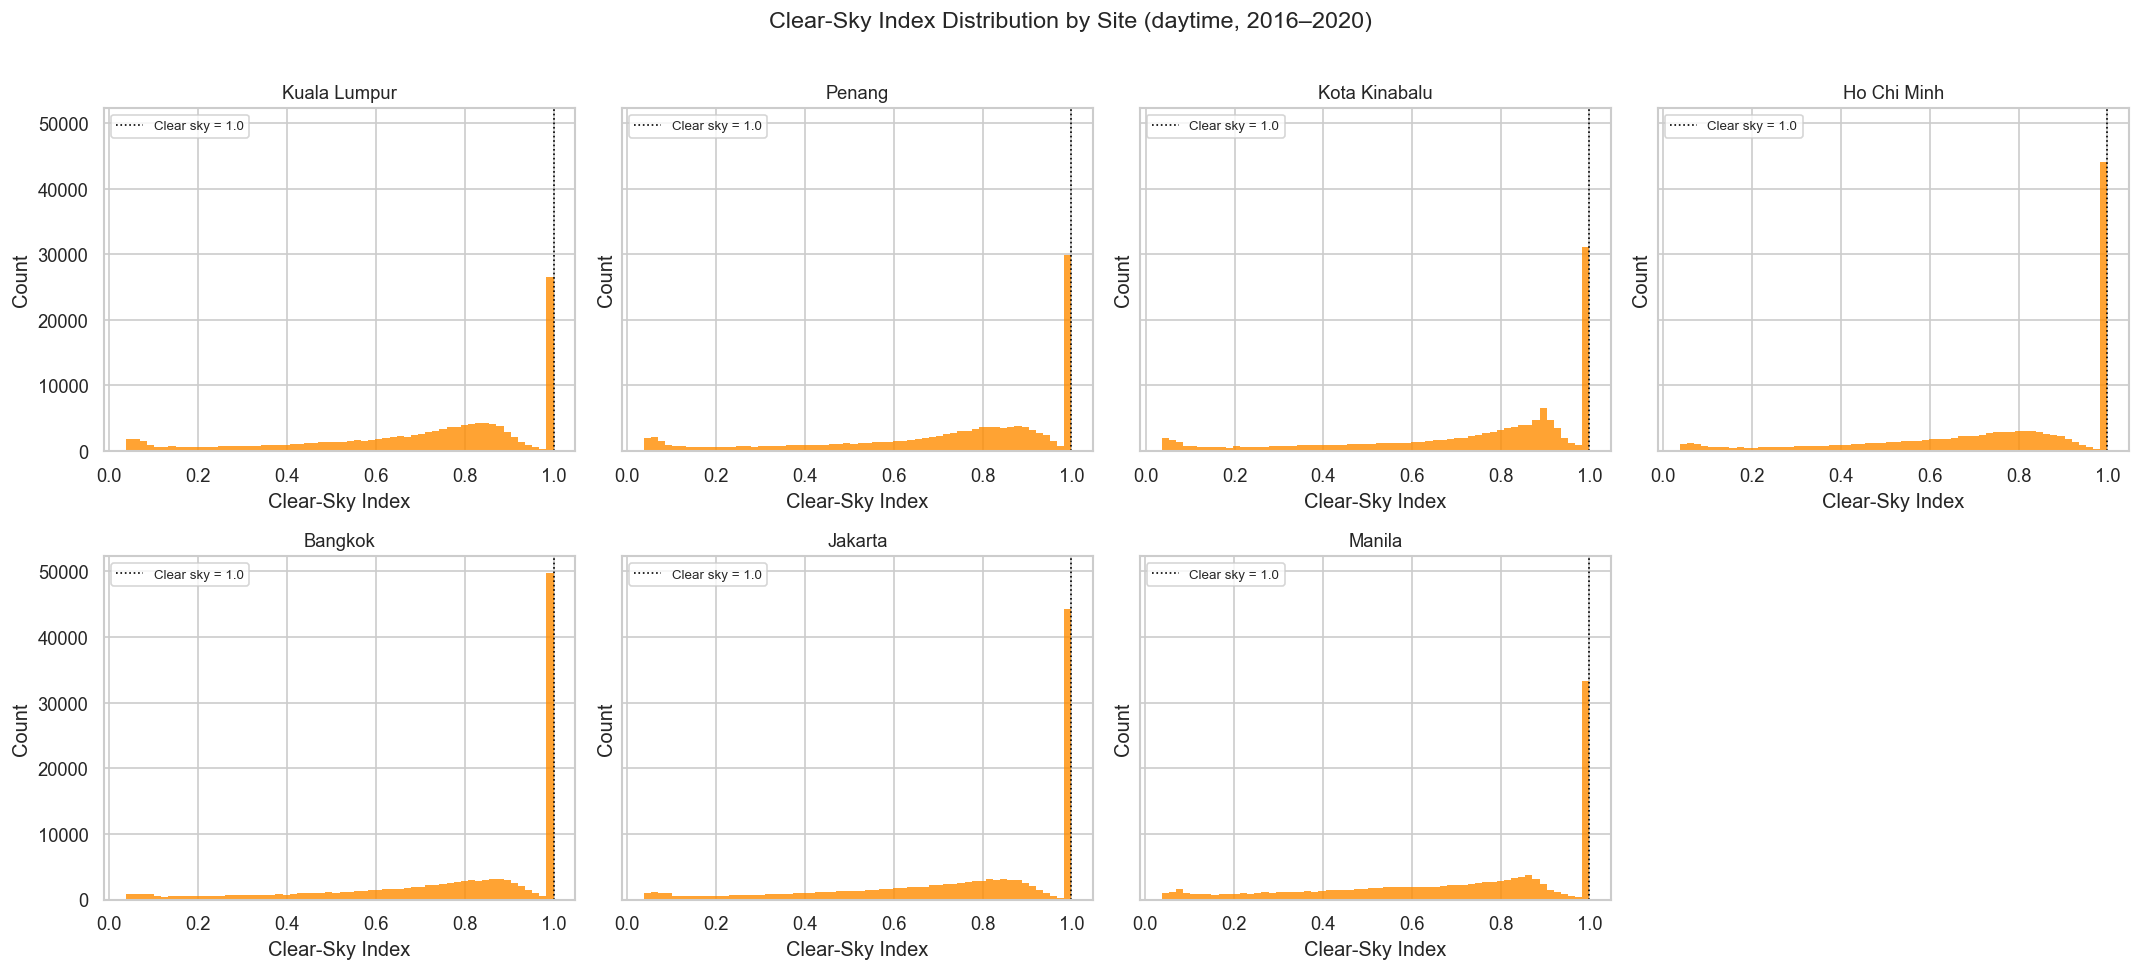

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for i, site in enumerate(SITES):
    ax = axes[i]
    # Daytime only, exclude nighttime zeros
    daytime = all_dfs[site][
        (all_dfs[site]['Clearsky GHI'] > 10) &
        (all_dfs[site]['GHI'] >= 0)
    ]['CSI']
    ax.hist(daytime.dropna(), bins=60, color='darkorange', edgecolor='none', alpha=0.8)
    ax.axvline(1.0, color='black', linewidth=1, linestyle=':', label='Clear sky = 1.0')
    ax.set_title(site.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Clear-Sky Index')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('Clear-Sky Index Distribution by Site (daytime, 2016–2020)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'csi_distribution.png'), bbox_inches='tight')
plt.show()

## 9. Sample Time Series — One Week Per Monsoon Season (KL)

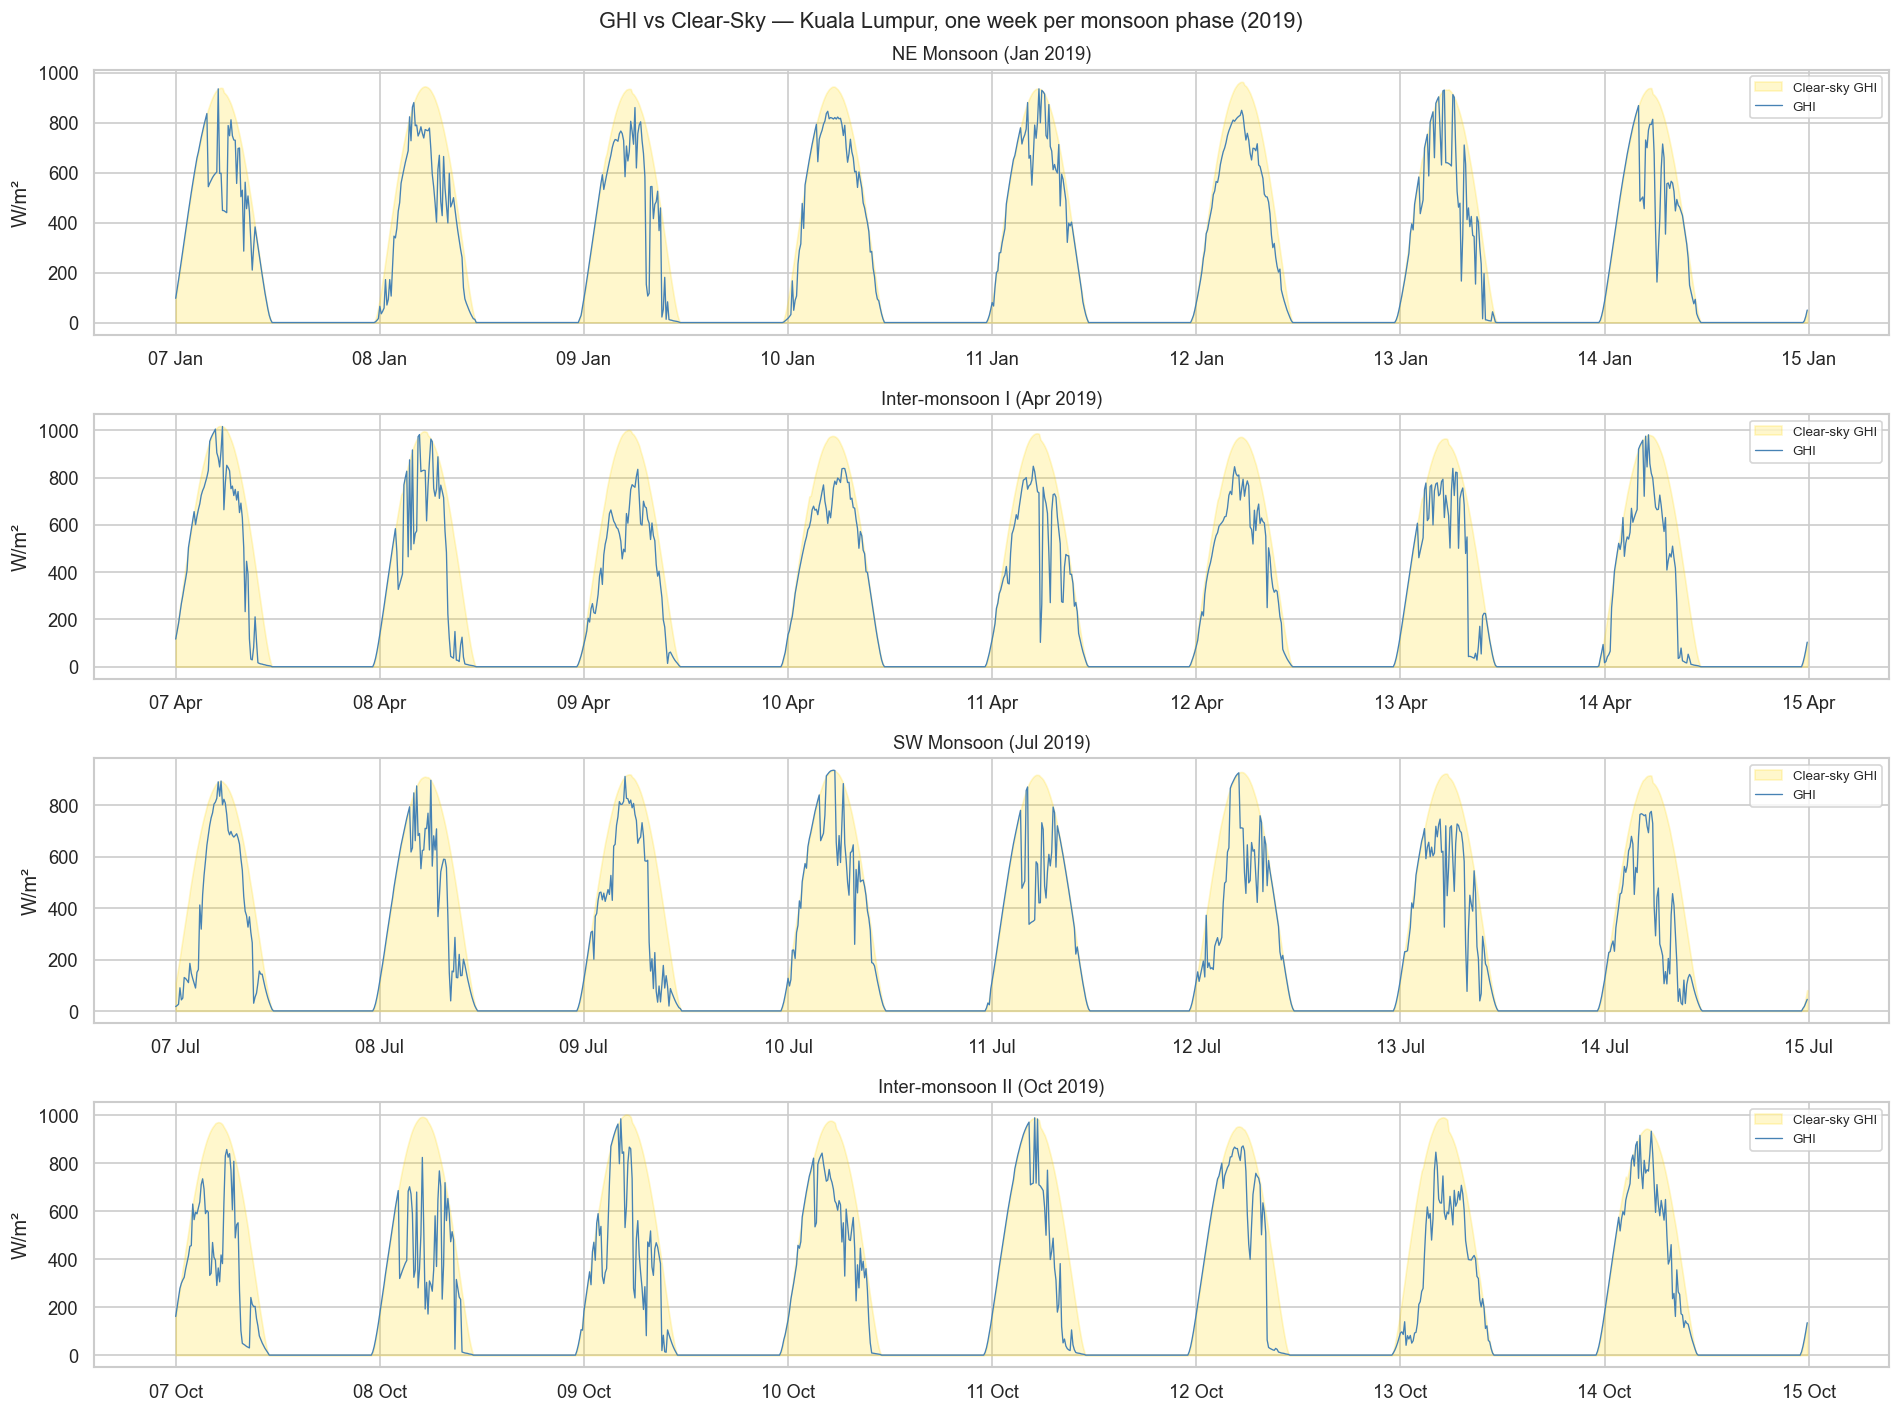

In [10]:
kl = all_dfs['kuala_lumpur']

# One representative week per monsoon phase
sample_weeks = {
    'NE Monsoon (Jan 2019)':    ('2019-01-07', '2019-01-14'),
    'Inter-monsoon I (Apr 2019)': ('2019-04-07', '2019-04-14'),
    'SW Monsoon (Jul 2019)':    ('2019-07-07', '2019-07-14'),
    'Inter-monsoon II (Oct 2019)': ('2019-10-07', '2019-10-14'),
}

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=False)

for ax, (label, (start, end)) in zip(axes, sample_weeks.items()):
    week = kl.loc[start:end]
    ax.fill_between(week.index, week['Clearsky GHI'], alpha=0.2, color='gold', label='Clear-sky GHI')
    ax.plot(week.index, week['GHI'], linewidth=0.8, color='steelblue', label='GHI')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('W/m²')
    ax.legend(fontsize=8, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

fig.suptitle('GHI vs Clear-Sky — Kuala Lumpur, one week per monsoon phase (2019)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ghi_timeseries_monsoon_weeks_kl.png'), bbox_inches='tight')
plt.show()

## 10. Summary Statistics Table

In [11]:
rows = []
for site, df in all_dfs.items():
    daytime = df[df['GHI'] > 0]
    csi_day = df[(df['Clearsky GHI'] > 10)]
    rows.append({
        'Site': site.replace('_', ' ').title(),
        'Total rows': f'{len(df):,}',
        'Daytime rows': f'{len(daytime):,}',
        'Mean GHI (W/m²)': f'{daytime["GHI"].mean():.1f}',
        'Max GHI (W/m²)': f'{daytime["GHI"].max():.0f}',
        'Mean CSI': f'{csi_day["CSI"].mean():.3f}',
        'Flag=0 (OK) %': f'{100 * (df["Fill Flag"] == 0).mean():.1f}%',
    })

summary = pd.DataFrame(rows).set_index('Site')
display(summary)

,Total rows,Daytime rows,Mean GHI (W/m²),Max GHI (W/m²),Mean CSI,Flag=0 (OK) %
Site,,,,,,
Kuala Lumpur,"263,088","130,827",411.2,1048,0.700,89.1%
Penang,"263,088","130,477",427.9,1049,0.718,87.8%
Kota Kinabalu,"263,088","130,744",444.9,1062,0.735,87.2%
Ho Chi Minh,"263,088","130,848",430.6,1051,0.747,88.9%
Bangkok,"263,088","130,748",437.2,1028,0.780,90.0%
Jakarta,"263,088","130,368",417.7,1036,0.751,89.7%
Manila,"263,088","130,645",383.8,1058,0.694,85.6%
